# GoEmotions Tail Label Analysis

Initial dataset analysis for the AI Lab project.

Goal:
- analyze label frequency distribution
- identify tail emotion categories
- check split stability

1. cella — csomagok telepítése

In [25]:
!pip install -q datasets pandas matplotlib

2. cella — importok

In [26]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

3. cella — dataset betöltése

In [27]:
dataset = load_dataset("go_emotions")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})

4. cella — label nevek lekérése

In [28]:
label_names = dataset["train"].features["labels"].feature.names
label_names

['admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral']

5. cella — gyakoriságok számítása minden splitre

In [29]:
def count_labels(split):
    counter = Counter()
    for row in dataset[split]:
        for label_id in row["labels"]:
            counter[label_id] += 1
    return counter

train_counter = count_labels("train")
validation_counter = count_labels("validation")
test_counter = count_labels("test")

6. cella — dataframe összeállítása

In [30]:
rows = []
for label_id, label_name in enumerate(label_names):
    rows.append({
        "label_id": label_id,
        "label": label_name,
        "train_count": train_counter.get(label_id, 0),
        "validation_count": validation_counter.get(label_id, 0),
        "test_count": test_counter.get(label_id, 0),
    })

df = pd.DataFrame(rows)
df["total_count"] = df["train_count"] + df["validation_count"] + df["test_count"]
df = df.sort_values("train_count", ascending=False).reset_index(drop=True)

df

,label_id,label,train_count,validation_count,test_count,total_count
0,27,neutral,14219,1766,1787,17772
1,0,admiration,4130,488,504,5122
2,4,approval,2939,397,351,3687
3,15,gratitude,2662,358,352,3372
4,3,annoyance,2470,303,320,3093
5,1,amusement,2328,303,264,2895
6,7,curiosity,2191,248,284,2723
7,18,love,2086,252,238,2576
8,10,disapproval,2022,292,267,2581
9,20,optimism,1581,209,186,1976


7. cella — tail label-ek meghatározása (bottom 30% a train gyakoriság alapján)

In [31]:
n_labels = len(df)
tail_size = max(1, round(n_labels * 0.30))

tail_df = df.sort_values("train_count", ascending=True).head(tail_size).copy()
tail_df = tail_df.sort_values("train_count", ascending=True).reset_index(drop=True)

print(f"Összes label: {n_labels}")
print(f"Tail méret (bottom 30%): {tail_size}")
tail_df

Összes label: 28
Tail méret (bottom 30%): 8


,label_id,label,train_count,validation_count,test_count,total_count
0,16,grief,77,13,6,96
1,21,pride,111,15,16,142
2,23,relief,153,18,11,182
3,19,nervousness,164,21,23,208
4,12,embarrassment,303,35,37,375
5,24,remorse,545,68,56,669
6,14,fear,596,90,78,764
7,8,desire,641,77,83,801


8. cella — teljes rendezett lista a train gyakoriság alapján

In [32]:
df_sorted_train = df.sort_values("train_count", ascending=False).reset_index(drop=True)
df_sorted_train

,label_id,label,train_count,validation_count,test_count,total_count
0,27,neutral,14219,1766,1787,17772
1,0,admiration,4130,488,504,5122
2,4,approval,2939,397,351,3687
3,15,gratitude,2662,358,352,3372
4,3,annoyance,2470,303,320,3093
5,1,amusement,2328,303,264,2895
6,7,curiosity,2191,248,284,2723
7,18,love,2086,252,238,2576
8,10,disapproval,2022,292,267,2581
9,20,optimism,1581,209,186,1976


9. cella — nagyon ritka / problémás címkék kigyűjtése

In [33]:
very_rare = df[df["train_count"] < 50].sort_values("train_count")
extremely_rare = df[df["train_count"] < 20].sort_values("train_count")

print("Train count < 50")
display(very_rare)

print("Train count < 20")
display(extremely_rare)

Train count < 50


,label_id,label,train_count,validation_count,test_count,total_count


Train count < 20


,label_id,label,train_count,validation_count,test_count,total_count


10. cella — split stabilitás ellenőrzése a tail label-ekre

In [34]:
tail_split_check = tail_df[["label", "train_count", "validation_count", "test_count"]].copy()
tail_split_check["min_split_count"] = tail_split_check[["train_count", "validation_count", "test_count"]].min(axis=1)
tail_split_check = tail_split_check.sort_values(["min_split_count", "train_count"], ascending=True).reset_index(drop=True)

tail_split_check

,label,train_count,validation_count,test_count,min_split_count
0,grief,77,13,6,6
1,relief,153,18,11,11
2,pride,111,15,16,15
3,nervousness,164,21,23,21
4,embarrassment,303,35,37,35
5,remorse,545,68,56,56
6,desire,641,77,83,77
7,fear,596,90,78,78


11. cella — oszlopdiagram a train label gyakoriságokról

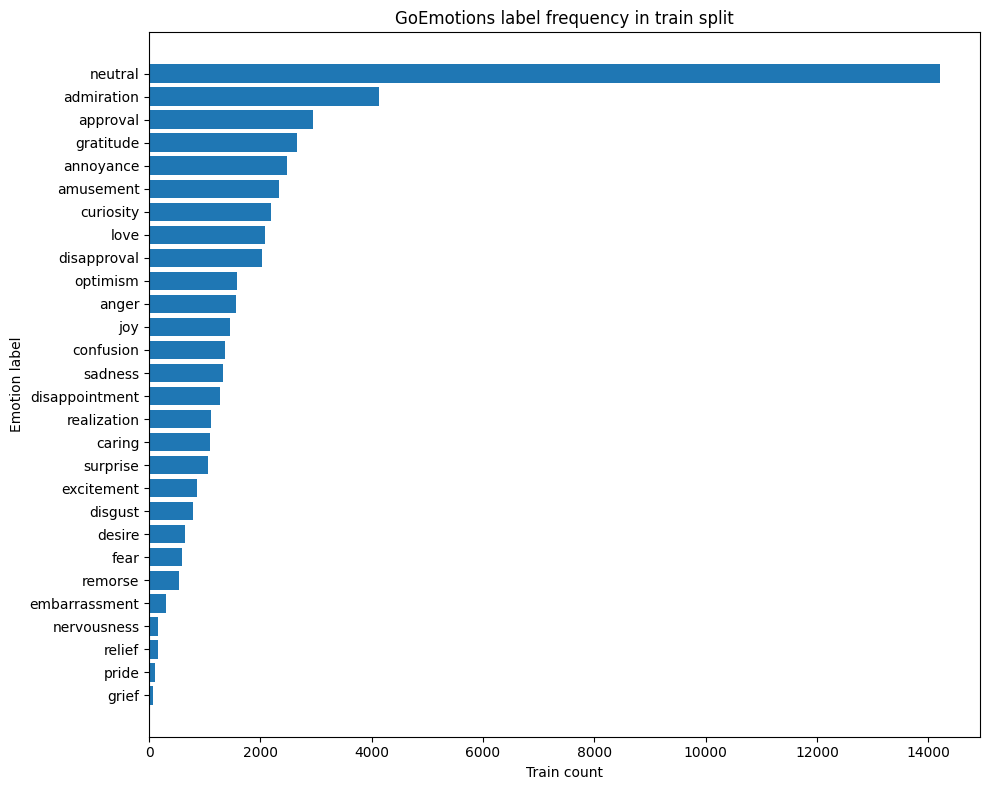

In [35]:
plot_df = df.sort_values("train_count", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["label"], plot_df["train_count"])
plt.xlabel("Train count")
plt.ylabel("Emotion label")
plt.title("GoEmotions label frequency in train split")
plt.tight_layout()
plt.show()

12. cella — tail label-ek külön ábrán

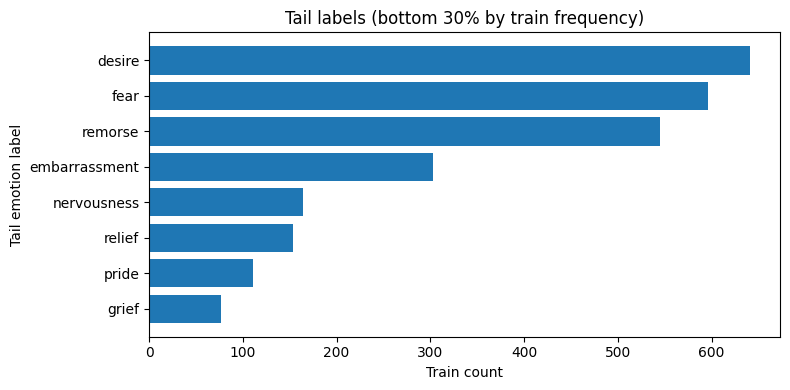

In [36]:
plt.figure(figsize=(8, 4))
plt.barh(tail_df["label"], tail_df["train_count"])
plt.xlabel("Train count")
plt.ylabel("Tail emotion label")
plt.title("Tail labels (bottom 30% by train frequency)")
plt.tight_layout()
plt.show()

13. cella — CSV mentés

In [37]:
df_sorted_train.to_csv("goemotions_label_frequencies.csv", index=False)
tail_df.to_csv("goemotions_tail_labels.csv", index=False)
tail_split_check.to_csv("goemotions_tail_split_check.csv", index=False)

print("Mentve:")
print("- goemotions_label_frequencies.csv")
print("- goemotions_tail_labels.csv")
print("- goemotions_tail_split_check.csv")

Mentve:
- goemotions_label_frequencies.csv
- goemotions_tail_labels.csv
- goemotions_tail_split_check.csv


14. cella — rövid szöveges összefoglaló generálása

In [38]:
tail_labels_list = ", ".join(tail_df["label"].tolist())

summary_lines = []
summary_lines.append(f"Total number of labels: {n_labels}")
summary_lines.append(f"Tail labels defined as the bottom 30% by train frequency: {tail_size} labels")
summary_lines.append(f"Tail labels: {tail_labels_list}")

if len(very_rare) > 0:
    summary_lines.append(f"Number of labels with train_count < 50: {len(very_rare)}")
if len(extremely_rare) > 0:
    summary_lines.append(f"Number of labels with train_count < 20: {len(extremely_rare)}")

summary_text = "\n".join(summary_lines)
print(summary_text)

Total number of labels: 28
Tail labels defined as the bottom 30% by train frequency: 8 labels
Tail labels: grief, pride, relief, nervousness, embarrassment, remorse, fear, desire


15. cella — státuszjelentéshez használható mondatok

In [41]:
status_text = """
Rövid heti státusz:

- elkészítettem a GoEmotions címkegyakoriság-analízisét a train / validation / test splitre,
- meghatároztam a tail kategóriákat a bottom 30% train gyakoriság alapján,
- kigyűjtöttem a tail-ben lévő érzelmeket és ellenőriztem, hogy vannak-e nagyon ritka / problémás címkék a split szempontjából,
- előkészítettem a „prioritize recall on tail labels” formalizálásához szükséges alapokat.
"""
print(status_text)


Rövid heti státusz:

- elkészítettem a GoEmotions címkegyakoriság-analízisét a train / validation / test splitre,
- meghatároztam a tail kategóriákat a bottom 30% train gyakoriság alapján,
- kigyűjtöttem a tail-ben lévő érzelmeket és ellenőriztem, hogy vannak-e nagyon ritka / problémás címkék a split szempontjából,
- előkészítettem a „prioritize recall on tail labels” formalizálásához szükséges alapokat.

